<a href="https://colab.research.google.com/github/voraciousnerd/iqm-quantum-school-labs/blob/main/QS_DAY1_Lab_participants.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantum School: Day 1 - Lab
We have been using a visual editor to create quantum circuits throughout the first session. Now it's time to create some circuits on your own using qrisp, the next generation quantum programming framework!

You can adjust the code to your liking and familiarize yourself with all the ideas that you have learned about.

In order to use qrisp together with IQM devices, please make sure to install the latest version of qrisp.

# How to set it up:

**Run the first cell.**

Install the appropriate packages for Python by running the following two cells below.

If you are prompted to restart your Colab session, do so once after running the second cell. After this restart, hit "Cancel" if you are prompted to restart again.

## Task 1: Signing up for IQM Resonance
If you do not have an IQM Resonance account, you can create an account. Make sure to use an e-mail address you have access to, as you will need to verify it.

## [Sign up to via this link to IQM Resonance](https://iqm.tech/sign-up-socials/)

Your account will grant you monthly credits to run quantum circuits on IQM's quantum hardware. We will use this account throughout the exercises.

## You will also need an access token to run jobs on Resonance.

**In Resonance, navigate into the profile settings section by clicking on your initials in the top right corner of the dashboard. You will be presented with the Access tokens area there.**

## Task 2 Instanciating QuantumVariables and creating different states
### Task 2.1: **Test the basic gates we will need today. - $H$, $X$,  $Z$**

Instanciate a QuantumVariable per gate and apply them to the states below. What change do expect to see?

#### Reference: Single-Qubit Quantum Gates
#### Hadamard Gate
$H = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}, \, \, H\lvert 1 \rangle = \frac{1}{\sqrt{2}} \left( \lvert 0 \rangle - \lvert 1 \rangle \right)$
#### X Gate (NOT Gate)
$X = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}, \, \, X\lvert 0 \rangle = \lvert 1 \rangle, \, X\lvert 1 \rangle = \lvert 0 \rangle$
#### Z Gate
$Z = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix} , \, \, Z\lvert 0 \rangle = \lvert 0  \rangle , \,   Z\lvert 1 \rangle = -\lvert 1 \rangle$

In [2]:
from qrisp import *


# create single-qubit variables
x_state = QuantumVariable(1)
z_state = QuantumVariable(1)
h_state = QuantumVariable(1)

# apply x, z and h gates

x(x_state)
z(z_state)
h(h_state)

# Printing a QuantumVariable outputs the probability of measuring the qubit to be in each basis state.

print(x_state.qs.statevector())
print(z_state.qs.statevector())
print(h_state.qs.statevector())

print("x_state: ", x_state)
print("z_state: ", z_state)
print("h_state: ", h_state)


|1>                                                                             
|0>                                                                             
sqrt(2)*(|0> + |1>)/2                                                           
{'1': 1.0}                                                                      
{'0': 1.0}                                                                      
{'0': 0.5, '1': 0.5}                                                            


### Task 2.2:
**Which gate will rotate a state around the red ring?**
Apply this gate below!

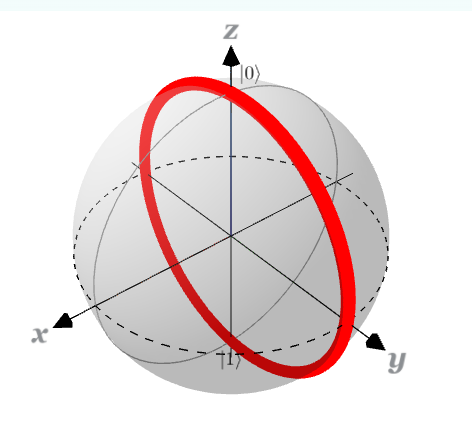

In [3]:
# Apply the rotation!
import numpy as np
rotated_state = QuantumVariable(1)

# TODO apply the correct gate!
x(rotated_state)
print(rotated_state)

{'1': 1.0}                                                                      


#### Task 2.3 (Homework):
Let's try something more complex, and extend our gate set.

Create the state

`sqrt(2)*(|0> + exp(3*I*pi/4)*|1>)/2` ($\approx 0.71|0\rangle + (-0.5+0.5i)|1\rangle$)

using `x`, `h`, `t`, `z`, `y` or `s` gates.

In [4]:
qubit = QuantumVariable(1)
# TODO: Apply gates to prepare the specified state

print(qubit.qs.statevector())
print(qubit)
print(str(qubit.qs.statevector()) == "sqrt(2)*(|0> + exp(3*I*pi/4)*|1>)/2")

|0>                                                                             
{'0': 1.0}                                                                      
False                                                                           


If you are curious about which state we created, you can apply the same operations on the Bloch sphere [here](https://www.iqmacademy.com/play/bloch/).


### Task 3: Creating entanglement using qrisp

In this task we will be creating entanglement using **qrisp** and simulating the circuits on the Qrisp simulator. We will send them to real hardware via **IQM Resonance** in Task 4.

### Task 3.1: Execute the following code in your environment.

It will create the  Bell state $|\Phi^+\rangle =\frac{1}{\sqrt{2}}(|00\rangle+|11\rangle)$, a special version of a maximally entangled state, and simulate it on the Qrisp simulator.

#### Reference: Two-Qubit Quantum Gates
#### CX Gate
$CX =\begin{pmatrix}1 & 0 & 0 & 0 \\0 & 1 & 0 & 0 \\0 & 0 & 0 & 1 \\0 & 0 & 1 & 0\end{pmatrix}$, $\mathrm{CX}\lvert 00\rangle = \lvert 00\rangle, \mathrm{CX}\lvert 01\rangle = \lvert 01\rangle, \mathrm{CX}\lvert 10\rangle = \lvert 11\rangle, \mathrm{CX}\lvert 11\rangle = \lvert 10\rangle$

In [5]:
phi_p = QuantumVariable(2)
h(phi_p[0])
cx(phi_p[0], phi_p[1])
# The qv.get_measurement() function behaves just like print(qv), but we'll need to use get_measurement() to run on a real quantum computer.
print(phi_p.qs.statevector())
phi_p.get_measurement()

sqrt(2)*(|00> + |11>)/2                                                         


{'00': 0.5, '11': 0.5}

Let's also take a look at the underlying circuit that was created. In `qrisp` this is done by accessing the `qs` attribute of the `QuantumVariable`.

In [6]:
print(phi_p.qs)

QuantumCircuit:
---------------
         ┌───┐     
phi_p.0: ┤ H ├──■──
         └───┘┌─┴─┐
phi_p.1: ─────┤ X ├
              └───┘
Live QuantumVariables:
----------------------
QuantumVariable phi_p


### Task 3.2: **Adjust the code below to create the three other bell states:**     
$|\Phi^-\rangle =\frac{1}{\sqrt{2}}(|00\rangle-|11\rangle)$  
$|\Psi^+\rangle =\frac{1}{\sqrt{2}}(|01\rangle+|10\rangle)$    
$|\Psi^-\rangle =\frac{1}{\sqrt{2}}(|01\rangle-|10\rangle)$
using Qrisp.

### **Hint**:
You always start with ``h(0th_qubit)``, followed by ``cx(0th_qubit, 1st_qubit)``. The rest is then a combination of correctly applied ``x()`` and ``z()`` gates.



In [7]:
from qrisp import QuantumVariable, h , cx, z, x

# |00> + |11>
phi_p = QuantumVariable(2)

# |00> - |11>
phi_m = QuantumVariable(2)

# |01> + |10>
psi_p = QuantumVariable(2)

# |01> - |10>
psi_m = QuantumVariable(2)
# remember:
# All gates are in-place operation
# You can look at a QuantumCircuit via print(phi_p.qs)

# Example: Gate combination to prepare phi_plus (|00> + |11>) state, same as above
h(phi_p[0])
cx(phi_p[0], phi_p[1])
print("phi_p:")
print(phi_p.qs.statevector())
print(phi_p)

# TODO: Apply gates to prepare phi_minus |00> - |11>
h(phi_m[0])
cx(phi_m[0], phi_m[1]) # 00 + 11
z(phi_m[0]) # 00 - 11

print("phi_m:")
print(phi_m.qs.statevector())
print(phi_m)

# TODO: Apply gates to prepare psi_plus |01> + |10>
h(psi_p[0])
cx(psi_p[0], psi_p[1]) # 00 + 11
x(psi_p[1])

print("psi_p:")
print(psi_p.qs.statevector())
print(psi_p)

# TODO: Apply gates to prepare psi_minus |01> - |10>

h(psi_m[0])
cx(psi_m[0], psi_m[1]) # 00 + 11
z(psi_m[0]) # 00 - 11
x(psi_m[1]) # 01 - 10

print("psi_m:")
print(psi_m.qs.statevector())
print(psi_m)

phi_p:
sqrt(2)*(|00> + |11>)/2                                                         
{'00': 0.5, '11': 0.5}                                                          
phi_m:
sqrt(2)*(|00> - |11>)/2                                                         
{'00': 0.5, '11': 0.5}                                                          
psi_p:
sqrt(2)*(|01> + |10>)/2                                                         
{'10': 0.5, '01': 0.5}                                                          
psi_m:
sqrt(2)*(|01> - |10>)/2                                                         
{'10': 0.5, '01': 0.5}                                                          


The first Bell state $|\Phi^+\rangle =\frac{1}{\sqrt{2}}(|00\rangle+|11\rangle)$  is also a special version of a GHZ state. A general GHZ state is described as $(|0\rangle^{\otimes n}+|1\rangle^{\otimes n})$, so an equal superposition between a state of all $|0\rangle$'s and all $|1\rangle$'s

Let's create a GHZ state with 3 qubits! For that go back to the Bell state circuit from Task 3.1 and fix that by adding another qubit and CNOT gate.

### Task 3.3: Modify the code below to create a GHZ state with 3 qubits.
Simulate the modified circuit on the qrisp simulator.

In [8]:
GHZ_3 = QuantumVariable(3)
h(GHZ_3[0])
cx(GHZ_3[0],GHZ_3[1]) # 00 + 11
# TODO: Apply gates to prepare GHZ |000> + |111>

cx(GHZ_3[1],  GHZ_3[2])


GHZ_3.get_measurement()

{'000': 0.5, '111': 0.5}

In [9]:
print(GHZ_3.qs)

QuantumCircuit:
---------------
         ┌───┐          
GHZ_3.0: ┤ H ├──■───────
         └───┘┌─┴─┐     
GHZ_3.1: ─────┤ X ├──■──
              └───┘┌─┴─┐
GHZ_3.2: ──────────┤ X ├
                   └───┘
Live QuantumVariables:
----------------------
QuantumVariable GHZ_3


### Important Note here:
Which qubit to control on?

## Task 4: Running circuits on IQM hardware

### The next two cells ask for your IQM Resonance API token and build the backend object `quantum_computer`.
**This is done once here and reused for the rest of the notebook** - you do not need to enter your token again later.

Your API key is available in your IQM Resonance account.

Navigate into the profile settings section by clicking on your initials in the top right corner of the dashboard. You will be presented with the Access tokens area there.

### Task 4.1: Modify the code below to evaluate some QuantumVariables

Do this for all of the QuantumVariables created in Task 2.1 (x_state, h_state,  z_state) and run the code on IQM's quantum hardware.

In [10]:

api_token = input()



In [11]:
from iqm.qrisp_iqm import IQMBackend
quantum_computer = IQMBackend(
    device_instance="garnet",
    token=api_token,
    server_url="https://resonance.iqm.tech/",
)

# The qv.get_measurement() function behaves just like print(qv), but we'll need to use get_measurement() to run on a real quantum computer.
phi_p.get_measurement(backend=quantum_computer, shots=10000)


{'00': 0.494, '11': 0.4767, '10': 0.0151, '01': 0.0142}

In [12]:
phi_p.get_measurement(backend=quantum_computer, shots=1000)

{'11': 0.516, '00': 0.452, '10': 0.017, '01': 0.015}

For your certificate, we asked you to submit the ID of a job that you ran on IQM Resonance. So let's do that now. The code below will let you extract the required ID, such that you can add to the attendance form.

In [13]:
x_state.get_measurement(backend=quantum_computer, shots=1000)
measure(x_state)

circuit = x_state.qs.compile()
job = quantum_computer.run_async(circuit)
print(f"Job ID: {job.job_id}")
print(f"Results: {job.result().get_counts()}")

Job ID: 01a03df4-c754-7833-a12b-c02cc2180aec
Results: {'0': 33, '1': 967}



### Task 4.2: Run the 3-qubit GHZ state from Task 3.3 on the hardware.

Simulating a GHZ state on the qrisp simulator is great, but you know what is even better? Running it on real quantum hardware!

The `quantum_computer` backend from Task 4.1 is still available, so we can send the circuit straight over.

In [14]:
GHZ_3.get_measurement(backend=quantum_computer)

{'000': 0.487, '111': 0.45, '011': 0.018, '110': 0.016, '101': 0.013, '001': 0.011, '100': 0.003, '010': 0.002}

### Task 4.3: Repeat the above experiment, but this time create a GHZ state with at least 10 qubits.



In [15]:
n_qubits = 10
ghz_10 = QuantumVariable(n_qubits)
# TODO: build a GHZ state on all n_qubits qubits and run it on the hardware#

print("Simulator:")
print(ghz_10.get_measurement())
print("Hardware:")
print(ghz_10.get_measurement(backend=quantum_computer, shots=1000))

Simulator:
{'0000000000': 1.0}                                                             
Hardware:
{'0000000000': 0.908, '0000001000': 0.034, '0010000000': 0.015, '0000000001': 0.008, '0001000000': 0.007, '0000000100': 0.006, '0000000010': 0.006, '1000000000': 0.004, '0100000000': 0.003, '0000010000': 0.003, '0000100000': 0.002, '1010000000': 0.001, '0100010000': 0.001, '0000011000': 0.001, '0010000010': 0.001}


**How does the result on the quantum hardware compare to the simulated results? Why?**


# TAKE A BREAK HERE!

There is more explaning to do :)

If other people are still working you may take this time to investigate the QR Codes on the presentation.



## Task 5: QuantumTypes

The sections below are part not part of today's Lab session.
**If you want to learn more Qrispy content, work through them at your own speed!**


All QuantumTypes inherit from the QuantumVariable class.

They are smoothly integrated into the typing infractructure of Python.Below you will see how to make use of QuantumFloats. They can be used for arithmetic operations such as addition, subtraction, etc.

### Task 5.1: Run the cell below.

In [16]:
from qrisp import QuantumFloat
a = QuantumFloat(3, -1, signed = False)

b = QuantumFloat(3, -2, signed = False)

a[:] = 1.5
b[:] = 0.25
c = a + b
print(c)

{1.75: 1.0}                                                                     


Lets try some multiplication:
### Task 5.2: Create a QuantumFloat equal to $\frac{1}{\sqrt{2}}(|8\rangle+|12\rangle)$

How to get there? Via multiplication!

We initialize one QuantumFloat ``qf_2`` in state $|4\rangle$. The other one needs to be in state $\frac{1}{\sqrt{2}}(|2\rangle+|3\rangle)$ or in binary $\frac{1}{\sqrt{2}}(|01\rangle+|11\rangle)$. It is your task to get the second one into the correct state, and then perform the multiplication

In [17]:
from qrisp import QuantumFloat

qf_1 = QuantumFloat(2)
# leave precision empty, it will then be equal to 0, which means we represent integers.
qf_2 = QuantumFloat(3)
qf_2[:] = 4

# put qf_1 in |01> state
x(qf_1[1])

# TODO: some additional manipulation is necessary! Put qf_1 into (|2> + |3>)/sqrt(2)


qf_res = qf_1*qf_2
print(qf_res)

{8: 1.0}                                                                        


### Task 5.3: Create a QuantumBool

QuantumFloats can be compared to Python floats using the established operators.
The return values are QuantumBools:

In [18]:
from qrisp import h
a = QuantumFloat(3)
h(a[2]) # |000> + |100> or as integers: |0> + |4>
print(a)

comparison_qbl_0 = (a < 4 )
print(comparison_qbl_0)

{0: 0.5, 4: 0.5}                                                                
{False: 0.5, True: 0.5}                                                         


# Homework:

## Task 6: Environments in Qrisp

In this task we will be investigating the ControlEnvironment using **Qrisp** and execute the circuits on a simulator as well as real hardware via **IQM Resonance**. Controlled operations are a central ingredient for many different algorithms. For you, they will be become the backbone of future your future quantum algorithms!

### Task 6.1: Execute the following code in your environment.
It will perform an addition on the QuantumFloat ``qf1``, controlled on the state of QuantumVariable ``qv_ctrl``.

In [19]:
from qrisp import gate_wrap, control, QuantumVariable,h,x

n_qubits = 2
qv_ctrl = QuantumVariable(n_qubits)
h(qv_ctrl) #
qf1 = QuantumFloat(3)
qf1[:] = 2

@gate_wrap
def some_subroutine(qf):
    qf +=2

for i in range(n_qubits): # iterate over both qubits in qv_ctrl
  with control(qv_ctrl[i]): # control on both qubits in qv_ctrl
      some_subroutine(qf1) # apply subroutine -> +2

print("The QuantumCircuit")
print(qf1.qs)

print("State of the control qv")
print(qv_ctrl)
# multi_measurement allows for structured measurement of multiple QuantumVariables
# This allows us to investigate the entanglement structure
print("State of the control qv + entanglement with qf1")
print(multi_measurement([qv_ctrl,qf1]))



The QuantumCircuit
QuantumCircuit:
---------------
           ┌───┐┌───────────────────────┐                         
qv_ctrl.0: ┤ H ├┤0                      ├─────────────────────────
           ├───┤│                       │┌───────────────────────┐
qv_ctrl.1: ┤ H ├┤                       ├┤0                      ├
           └───┘│                       ││                       │
    qf1.0: ─────┤1 cusc_some_subroutine ├┤1                      ├
           ┌───┐│                       ││  cusc_some_subroutine │
    qf1.1: ┤ X ├┤2                      ├┤2                      ├
           └───┘│                       ││                       │
    qf1.2: ─────┤3                      ├┤3                      ├
                └───────────────────────┘└───────────────────────┘
Live QuantumVariables:
----------------------
QuantumVariable qv_ctrl
QuantumFloat qf1
State of the control qv
{'00': 0.25, '10': 0.25, '01': 0.25, '11': 0.25}                                
State of the control

**How well does this work on the hardware?**

Let us see below

In [20]:
print(qf1.get_measurement(backend=quantum_computer, shots=1000))

{4: 0.317, 2: 0.288, 6: 0.13, 0: 0.113, 3: 0.061, 5: 0.047, 7: 0.031, 1: 0.013}


### Task 6.2:

Now let us do the following: Let us perform an operation controlled on two subsequent qubits, i.e.:

**We want to add 2 to QuantumFloat ``qf``, if two subsequent qubits in another QuantumFloat ``qf_ctrl`` are |1⟩.**

In [21]:
from qrisp import gate_wrap, control,QuantumVariable,h,x
n_qubits = 3
qf_ctrl = QuantumVariable(n_qubits)
h(qf_ctrl)
qf2 = QuantumFloat(4)
qf2[:] = 2

@gate_wrap
def some_subroutine(qf):

  qf +=2

for i in range(n_qubits-1): # decrease max index by one
#TODO
  pass

print("qf2")
print(qf2)
print("multi_measurement")
print(multi_measurement([qf_ctrl,qf2]))

# qf
#{2: 0.625, 4: 0.25, 6: 0.125}

# multi_measurement
#{('000', 2): 0.125, ('100', 2): 0.125, ('010', 2): 0.125, ('110', 4): 0.125, ('001', 2): 0.125, ('101', 2): 0.125, ('011', 4): 0.125, ('111', 6): 0.125}

qf2
{2: 1.0}                                                                        
multi_measurement
{('000', 2): 0.125, ('100', 2): 0.125, ('010', 2): 0.125, ('110', 2): 0.125, ('001', 2): 0.125, ('101', 2): 0.125, ('011', 2): 0.125, ('111', 2): 0.125}


Feel free to have a look at the QuantumSession aswell! The complexity of the circuit and a lack of hardware aware compilation are the main culprits for the introduced error.

In [22]:
print(qf2.qs)

QuantumCircuit:
---------------
           ┌───┐
qf_ctrl.0: ┤ H ├
           ├───┤
qf_ctrl.1: ┤ H ├
           ├───┤
qf_ctrl.2: ┤ H ├
           └───┘
    qf2.0: ─────
           ┌───┐
    qf2.1: ┤ X ├
           └───┘
    qf2.2: ─────
                
    qf2.3: ─────
                
Live QuantumVariables:
----------------------
QuantumVariable qf_ctrl
QuantumFloat qf2






## Outlook: More qrispy content

Qrisp offers plenty more of in-built functionality: more data types, arithmetic operations and built-in algorithm primitives (more on this at a later stage).

## More quantum types

For now, let's see some other data types available in qrisp!
One that is used, for example, in Shor's algorithm is the Quantum Modulus type.
It represents elements of a residue class ring, that is, integers modulo $n$.

### Task :
Run the code snippet below, then play with the parameters to make sure you understand how QuantumModulus works.

In [23]:
qm = QuantumModulus(3)  # represent elements of Z/ 3Z
qm[:] = 2
print(qm)

{2: 1.0}                                                                        


In [24]:
qm2 = qm + qm # addition in Z/3Z
print(qm2)

{1: 1.0}                                                                        


In [25]:
h(qm[1])

Qubit(qf_0.1)

In [26]:
print(qm)

{0: 0.5, 2: 0.5}                                                                


## Quantum Arrays

Qrisp also supports Quantum Arrays, which are collections of quantum variables. You can create a Quantum Array like this:

```python
qa = QuantumArray(qtype = QuantumVariable(1), shape = 4)  # Creates a Quantum Array of 4 qubits
```

### Task : fill in the code below to use the QuantumArray data type to create a GHZ state with 10 qubits and run it on a real quantum computer.

In [1]:
qa = QuantumArray(qtype = QuantumVariable(1), shape = 10)  # Creates a Quantum Array of 10 qubits

# TODO: implement GHZ state preparation
def GHZ(qv):
    print("Hello")

NameError: name 'QuantumArray' is not defined